In [15]:

!pip install pandas scikit-learn imbalanced-learn matplotlib seaborn



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

DATA_PATH = "creditcard.csv"   # download from Kaggle, place in your notebook folder
OUTDIR = Path("fraud_output")
os.makedirs(OUTDIR, exist_ok=True)

sns.set_theme(style="whitegrid")

In [6]:
df = pd.read_csv(DATA_PATH)
fraud_rate = df["Class"].mean() * 100
print(f"Loaded {len(df)} transactions. Fraud rate: {fraud_rate:.4f}%")
df.head()

Loaded 284807 transactions. Fraud rate: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


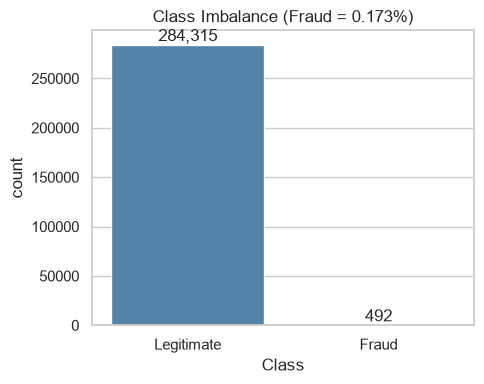

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="Class", hue="Class", palette=["steelblue", "crimson"], legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Legitimate", "Fraud"])
ax.set_title(f"Class Imbalance (Fraud = {df['Class'].mean()*100:.3f}%)")
for i, count in enumerate(df["Class"].value_counts().sort_index()):
    ax.text(i, count, f"{count:,}", ha="center", va="bottom")
plt.tight_layout()
fig.savefig(OUTDIR / "class_imbalance.png", dpi=150)
plt.show()

In [8]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} ({y_train.sum()} fraud)")
print(f"Test: {len(X_test)} ({y_test.sum()} fraud)")

Train: 227845 (394 fraud)
Test: 56962 (98 fraud)


In [9]:
logreg_pipeline = ImbPipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

logreg_param_grid = {
    "smote__k_neighbors": [3, 5],
    "classifier__C": [0.1, 1.0],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
logreg_grid = GridSearchCV(logreg_pipeline, logreg_param_grid, scoring="roc_auc", cv=cv, n_jobs=-1, verbose=1)
logreg_grid.fit(X_train, y_train)

print(f"\nBest params: {logreg_grid.best_params_}")
print(f"Best CV ROC-AUC: {logreg_grid.best_score_:.4f}")
logreg_model = logreg_grid.best_estimator_

Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best params: {'classifier__C': 0.1, 'smote__k_neighbors': 3}
Best CV ROC-AUC: 0.9752


In [10]:
rf_pipeline = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1)),
])

rf_param_grid = {
    "smote__k_neighbors": [5],
    "classifier__n_estimators": [100],   # reduced from [100, 200]
    "classifier__max_depth": [10],       # reduced from [10, None]
}

cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)  # reduced from 3
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, scoring="roc_auc", cv=cv, n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print(f"\nBest params: {rf_grid.best_params_}")
print(f"Best CV ROC-AUC: {rf_grid.best_score_:.4f}")

rf_model = rf_grid.best_estimator_

Fitting 2 folds for each of 1 candidates, totalling 2 fits

Best params: {'classifier__max_depth': 10, 'classifier__n_estimators': 100, 'smote__k_neighbors': 5}
Best CV ROC-AUC: 0.9802


In [11]:
def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"\n{name} — Test set evaluation:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"]))

    return {
        "model": name, "precision": precision, "recall": recall, "roc_auc": roc_auc,
        "predictions": y_pred, "probabilities": y_proba,
    }

results = [
    evaluate_model(logreg_model, "Logistic Regression", X_test, y_test),
    evaluate_model(rf_model, "Random Forest", X_test, y_test),
]


Logistic Regression — Test set evaluation:
  Precision: 0.0589
  Recall:    0.9184
  ROC-AUC:   0.9715
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


Random Forest — Test set evaluation:
  Precision: 0.5210
  Recall:    0.8878
  ROC-AUC:   0.9849
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.52      0.89      0.66        98

    accuracy                           1.00     56962
   macro avg       0.76      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962



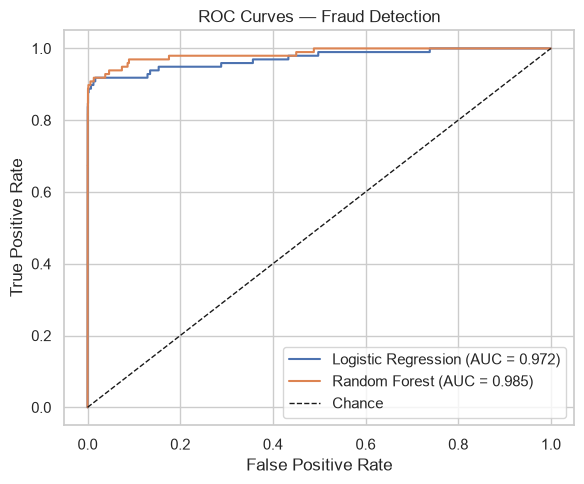

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
for res in results:
    fpr, tpr, _ = roc_curve(y_test, res["probabilities"])
    ax.plot(fpr, tpr, label=f"{res['model']} (AUC = {res['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Fraud Detection")
ax.legend()
plt.tight_layout()
fig.savefig(OUTDIR / "roc_curves.png", dpi=150)
plt.show()

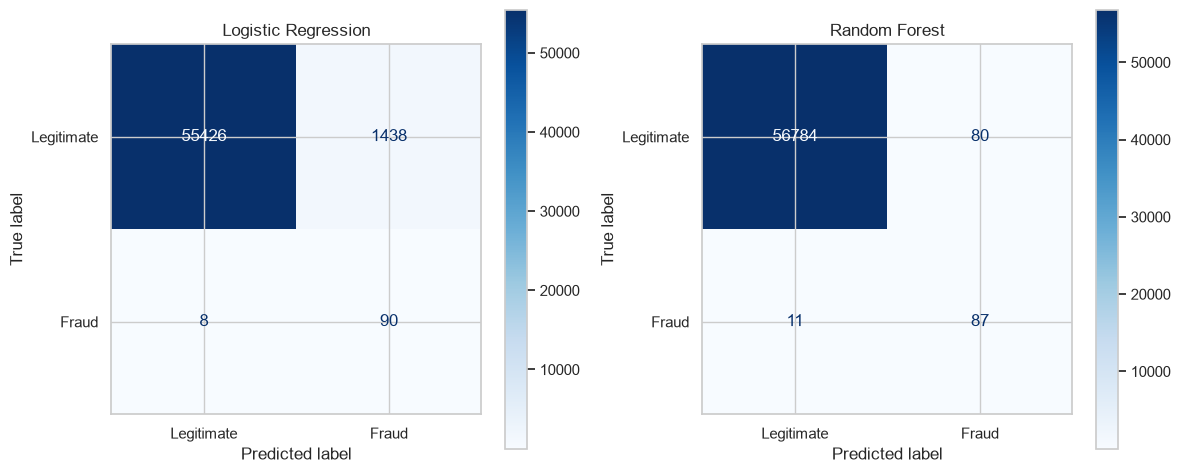

In [13]:
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
for ax, res in zip(axes, results):
    ConfusionMatrixDisplay.from_predictions(
        y_test, res["predictions"], display_labels=["Legitimate", "Fraud"], ax=ax, cmap="Blues"
    )
    ax.set_title(res["model"])
plt.tight_layout()
fig.savefig(OUTDIR / "confusion_matrices.png", dpi=150)
plt.show()

In [14]:
comparison_df = pd.DataFrame(
    [{"model": r["model"], "precision": r["precision"], "recall": r["recall"], "roc_auc": r["roc_auc"]}
     for r in results]
).sort_values("roc_auc", ascending=False)

comparison_df.to_csv(OUTDIR / "model_comparison.csv", index=False)
print("Final model comparison (sorted by ROC-AUC):")
comparison_df

Final model comparison (sorted by ROC-AUC):


,model,precision,recall,roc_auc
1,Random Forest,0.520958,0.887755,0.984869
0,Logistic Regression,0.058901,0.918367,0.971540


In [16]:
import os
print(os.listdir("fraud_output"))

['class_imbalance.png', 'confusion_matrices.png', 'model_comparison.csv', 'roc_curves.png']
